In [19]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [2]:
with open('../data/raw/cifar-10-batches-py/test_batch', 'rb') as f:
    batch = pickle.load(f, encoding='bytes')

images = batch[b'data']
labels = batch[b'labels']

print(images.shape)

(10000, 3072)


/tmp/ipykernel_320268/3866535505.py:2: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(f, encoding='bytes')


In [3]:
probs = np.load("../data/raw/cifar10h-probs.npy")

print(probs.shape)
print(probs[0].sum())

(10000, 10)
1.0


Hard label: 3
Soft label: [0.         0.01960784 0.01960784 0.94117647 0.         0.01960784
 0.         0.         0.         0.        ]


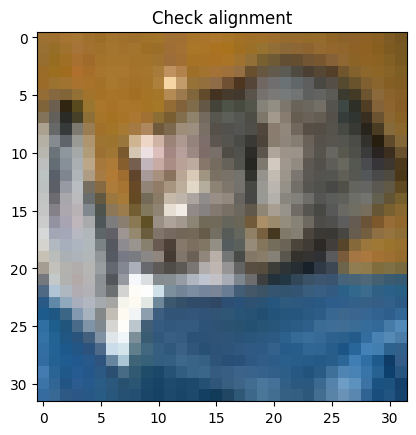

In [4]:
idx = 0

img = images[idx].reshape(3, 32, 32)
img = np.transpose(img, (1, 2, 0))

print("Hard label:", labels[idx])
print("Soft label:", probs[idx])

plt.imshow(img)
plt.title("Check alignment")
plt.show()

In [8]:
import seaborn as sns
from scipy.stats import entropy


In [9]:
true_entropies = np.array([entropy(p, base=2) for p in probs])

print("Min:", true_entropies.min())
print("Max:", true_entropies.max())
print("Mean:", true_entropies.mean())

Min: 0.0
Max: 2.8601764224723105
Mean: 0.2228380763829784


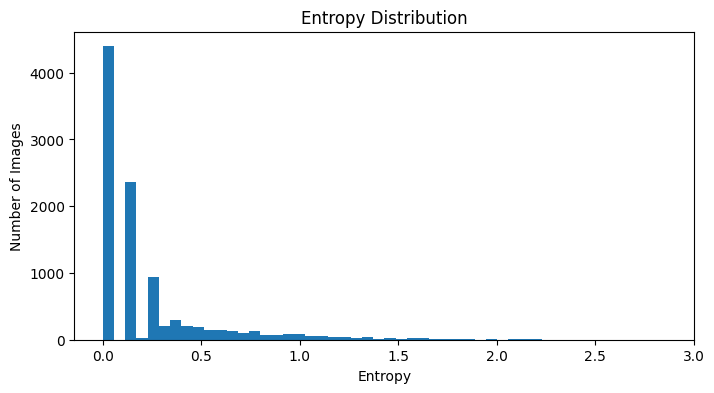

In [10]:
plt.figure(figsize=(8,4))
plt.hist(true_entropies, bins=50)
plt.xlabel("Entropy")
plt.ylabel("Number of Images")
plt.title("Entropy Distribution")
plt.show()

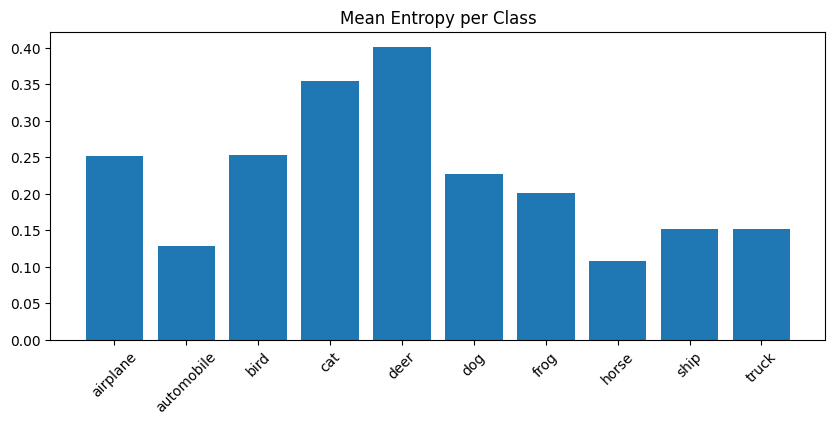

In [ ]:
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

per_class_entropy = [
    true_entropies[hard_labels == c].mean()
    for c in range(10)
]

plt.figure(figsize=(10,4))
plt.bar(classes, per_class_entropy)
plt.xticks(rotation=45)
plt.title("Mean Entropy per Class")
plt.show()

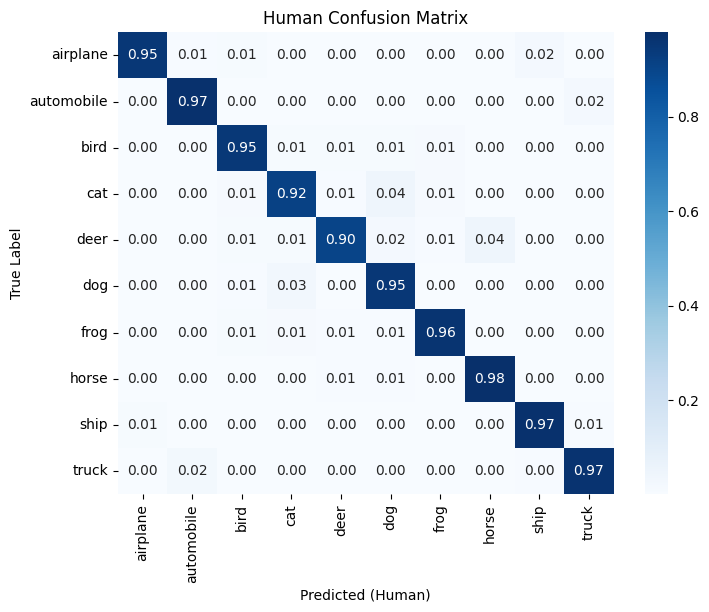

In [12]:
confusion = np.zeros((10,10))

for p, true_label in zip(probs, hard_labels):
    confusion[true_label] += p

confusion = confusion / confusion.sum(axis=1, keepdims=True)

plt.figure(figsize=(8,6))
sns.heatmap(confusion, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=classes, yticklabels=classes)

plt.xlabel("Predicted (Human)")
plt.ylabel("True Label")
plt.title("Human Confusion Matrix")
plt.show()

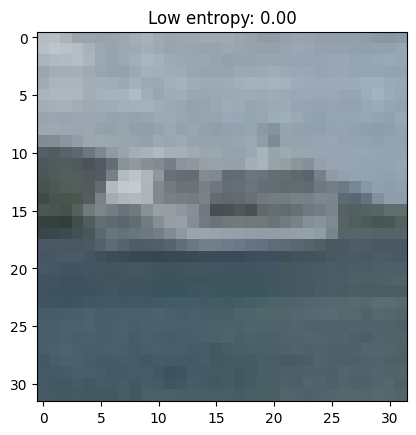

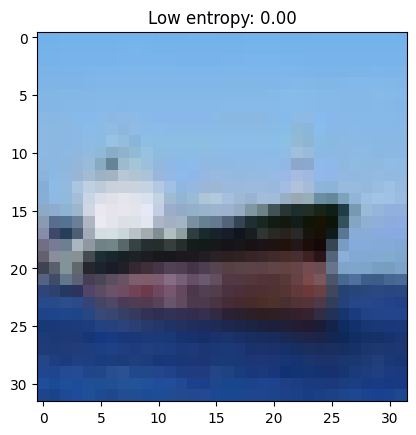

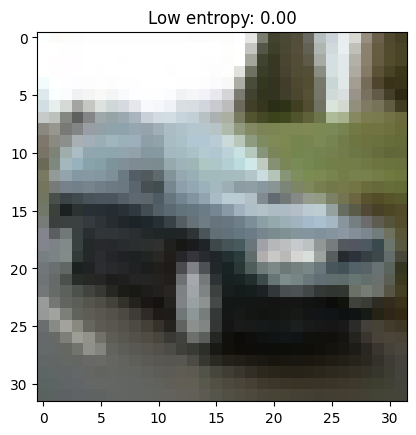

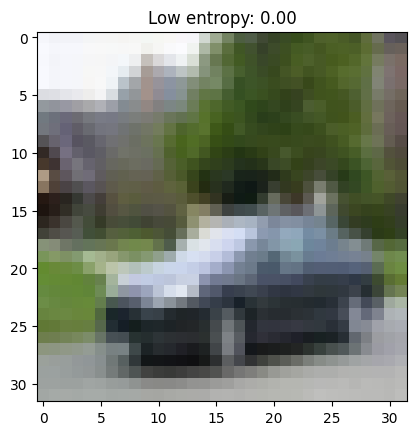

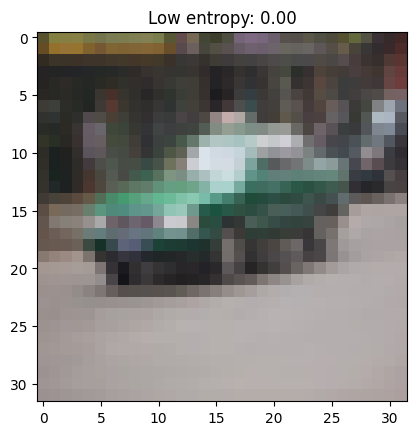

In [13]:
low_idx = np.argsort(true_entropies)[:5]
high_idx = np.argsort(true_entropies)[-5:]

for idx in low_idx:
    img = images[idx].reshape(3,32,32)
    img = np.transpose(img, (1,2,0))

    plt.imshow(img)
    plt.title(f"Low entropy: {true_entropies[idx]:.2f}")
    plt.show()

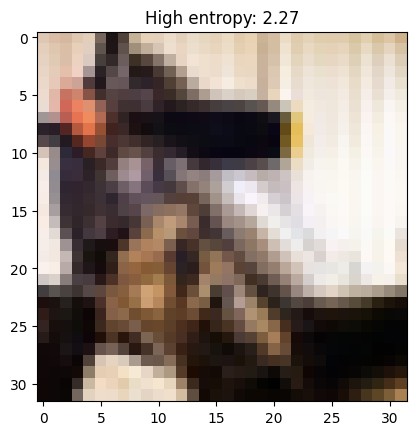

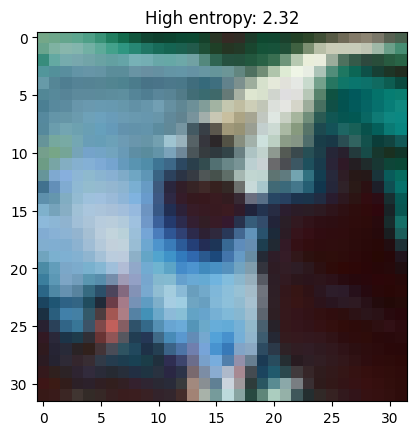

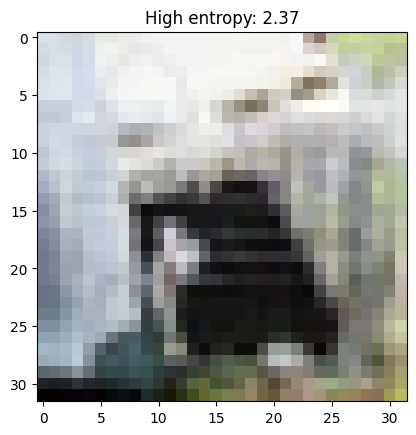

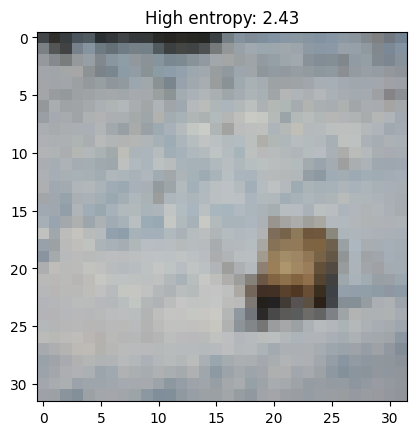

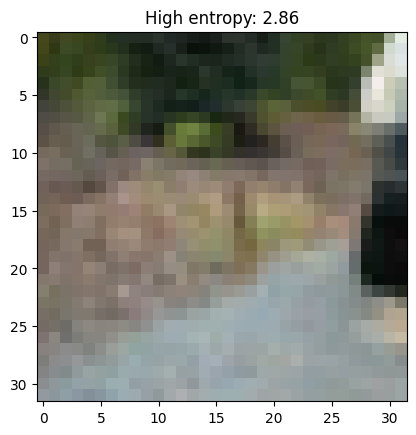

In [14]:
for idx in high_idx:
    img = images[idx].reshape(3,32,32)
    img = np.transpose(img, (1,2,0))

    plt.imshow(img)
    plt.title(f"High entropy: {true_entropies[idx]:.2f}")
    plt.show()

In [21]:
from sklearn.model_selection import train_test_split
from config import SEED

indices = np.arange(10000)

train_val_idx, test_idx = train_test_split(
    indices, test_size=2000, random_state=SEED
)
train_idx, val_idx = train_test_split(
    indices, test_size=2000, random_state=SEED
)

In [23]:
np.save('../data/processed/train_idx.npy', train_idx)
np.save('../data/processed/val_idx.npy', val_idx)
np.save('../data/processed/test_idx.npy', test_idx)

In [25]:
from src.dataset import CIFAR10HDataset

train_dataset = CIFAR10HDataset(images, probs, train_idx)

img, label = train_dataset[0]

print(img.shape)
print(label)

torch.Size([3, 32, 32])
tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0392, 0.0000, 0.9608, 0.0000,
        0.0000])


In [32]:
import torch
from src.model import DissagreementPredictor

model = DissagreementPredictor(head='linear')

x = torch.randn(1, 3, 32, 32)
y = model(x)

print(y.shape)
print(y)
print(y.sum())

/media/introverted-duck/New Volume/codes/devudaaaaa/human_annotator_disagreement_predictor/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/media/introverted-duck/New Volume/codes/devudaaaaa/human_annotator_disagreement_predictor/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


torch.Size([1, 10])
tensor([[0.1383, 0.1946, 0.0815, 0.1034, 0.0393, 0.1000, 0.0596, 0.0726, 0.1268,
         0.0840]], grad_fn=<SoftmaxBackward0>)
tensor(1., grad_fn=<SumBackward0>)


In [33]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

print(count_params(model))

(11173962, 11173962)


In [36]:
import torch
from src.losses import kl_divergence_loss, entropy_calibrated_kl_loss

p = torch.tensor([[0.6, 0.4]])
q = torch.tensor([[0.5, 0.5]])

print(kl_divergence_loss(q, p))
print(entropy_calibrated_kl_loss(q,p))

tensor(0.0201)
tensor(0.0203)
